In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/whatsapp-20250329-141239-processed.parquet")

df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,date,is_carnaval
0,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0,0,2023-09-01,False
1,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0,0,2023-09-01,False
2,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0,1,2023-09-01,False
3,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0,2,2023-09-01,False
4,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0,0,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...
8206,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0,0,2025-03-16,False
8207,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0,2,2025-03-16,False
8208,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0,0,2025-03-16,False
8209,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0,2,2025-03-17,False


In [27]:
import re

# Clean de data nog wat meer

def remove_url(text):
    return re.sub(r"^https?:\/\/.*[\r\n]*", "", text)


df["message"] = df["message"].apply(lambda x: str(x).replace("\n", " "))
df["message"] = df["message"].apply(lambda x: remove_url(x))
df["message"] = df["message"].apply(lambda x: x.lower())

df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,date,is_carnaval
0,2023-09-01 10:53:30,sprightly-rhinoceros,wat we triestig weer zeg man man man,38,33.0,m,0.0,0,2023-09-01,False
1,2023-09-01 10:56:11,snappy-ermine,pff echt he,13,30.0,m,0.0,0,2023-09-01,False
2,2023-09-01 10:56:39,decorated-shark,duurt nog ff....pfffff 😢,26,55.0,f,0.0,1,2023-09-01,False
3,2023-09-01 10:57:03,snappy-ermine,na vandaag wel goed weer op komst lijkt 👌🏼,44,30.0,m,0.0,2,2023-09-01,False
4,2023-09-01 10:58:44,decorated-shark,"oh, gelukkig.",15,55.0,f,0.0,0,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...
8206,2025-03-16 16:12:35,good-natured-ermine,als ze aan zet echt niet normaal,34,25.0,f,0.0,0,2025-03-16,False
8207,2025-03-16 17:16:14,crystalline-turkey,"thanks 😊 ff tussenstop op tenerife, crew wiss...",62,37.0,m,0.0,2,2025-03-16,False
8208,2025-03-16 22:33:05,crystalline-turkey,"wij zijn weer in nederland, net de wieltjes w...",62,37.0,m,0.0,0,2025-03-16,False
8209,2025-03-17 07:24:32,groovy-salmon,welcome back! 💪🏻,18,35.0,m,0.0,2,2025-03-17,False


In [54]:
# Tekststukken van ongeveer 200 woorden maken.

from sklearn.utils import shuffle

# Zet alle berichten per persoon aan elkaar vast
grouped = df.groupby('author')['message'].apply(lambda x: ' '.join(str(m) for m in x)).reset_index()

# Split in chunks van 200 woorden
def split_text(text, chunk_size=200):
    words = text.split()
    return [' '.join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]

chunk_data = []

for _, row in grouped.iterrows():
    chunks = split_text(row['message'], 200)
    for chunk in chunks:
        if len(chunk.split()) > 20:  # Alleen chunks met genoeg woorden
            chunk_data.append({'author': row['author'], 'text': chunk})

In [63]:
from collections import Counter

# Tel chunks per auteur
author_counts = Counter([row['author'] for row in chunk_data])

# Maak een lijst met alleen auteurs met minimaal 20 chunks
auteurs_min_20 = {auteur for auteur, count in author_counts.items() if count >= 20}

# Filter de chunk_data
chunk_data_filtered = [row for row in chunk_data if row['author'] in auteurs_min_20]

# Eventueel omzetten naar een DataFrame
chunks_df = pd.DataFrame(chunk_data_filtered)

print(chunks_df['author'].value_counts())
print(chunks_df.author.nunique())

author
groovy-salmon           42
good-natured-ermine     39
decorated-shark         27
crystalline-turkey      26
sprightly-rhinoceros    24
amusing-owl             21
Name: count, dtype: int64
6


In [64]:
# # het model snapt geen tekst, dus omzetten in een cijfer-representatie

# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(max_features=1000)
# X = vectorizer.fit_transform(chunks_df['text'])

# X

from sklearn.feature_extraction.text import CountVectorizer

# Vectoriseer met character 3-grams
vectorizer = CountVectorizer(analyzer="char", ngram_range=(3, 3))
X = vectorizer.fit_transform(chunks_df["text"])

from sklearn.metrics.pairwise import manhattan_distances

distance = manhattan_distances(X, X)
distance.shape, type(distance)

((179, 179), numpy.ndarray)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Verdeel in train en test data: 20% testdata & 42 is het antwoord op alles :)
X_train, X_test, y_train, y_test = train_test_split(distance, chunks_df['author'], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)


                      precision    recall  f1-score   support

         amusing-owl       1.00      0.80      0.89         5
  crystalline-turkey       1.00      1.00      1.00         5
     decorated-shark       1.00      1.00      1.00         5
 good-natured-ermine       1.00      1.00      1.00         7
       groovy-salmon       0.92      1.00      0.96        11
sprightly-rhinoceros       1.00      1.00      1.00         3

            accuracy                           0.97        36
           macro avg       0.99      0.97      0.97        36
        weighted avg       0.97      0.97      0.97        36





| **Metric**   | **Betekenis** |
|--------------|---------------|
| **Precision** | Hoe vaak het model juist is als het zegt "dit is van persoon X". |
| **Recall**    | Hoe goed het model álle stukjes van persoon X weet te herkennen. |
| **F1-score**  | Een soort gemiddelde van precision en recall. |
| **Support**   | Het aantal test-chunks per persoon (dus hoeveel stukjes tekst er per persoon zijn in de testset). |


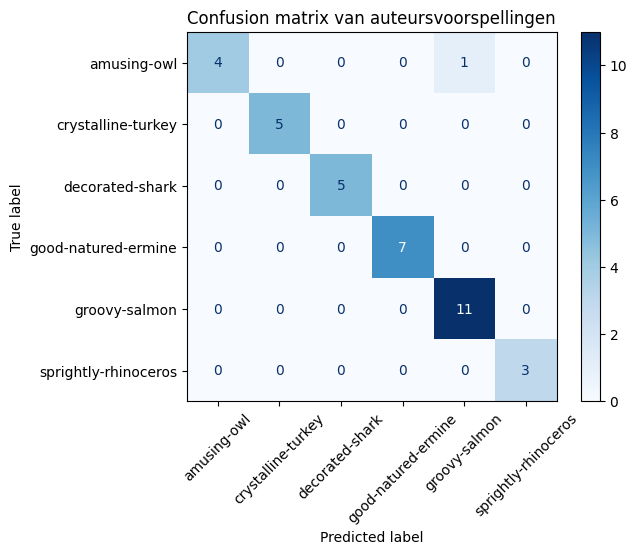

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_test: echte labels
# y_pred: voorspellingen van het model

# confusion matrix laat zien wanneer het model goed en fout voorspelt
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion matrix van auteursvoorspellingen")
plt.show()


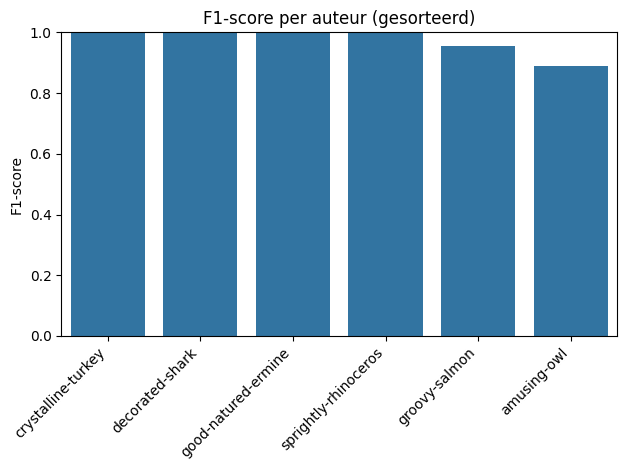

In [67]:
from sklearn.metrics import classification_report
import seaborn as sns

# Genereer classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Haal f1-scores op en filter alleen bekende klassen
f1_scores = {label: metrics["f1-score"] for label, metrics in report.items() if label in model.classes_}

# Sorteer op f1-score van hoog naar laag
sorted_f1 = dict(sorted(f1_scores.items(), key=lambda item: item[1], reverse=True))

# Plot gesorteerde scores
sns.barplot(x=list(sorted_f1.keys()), y=list(sorted_f1.values()))
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("F1-score per auteur (gesorteerd)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_model = pca.fit_transform(distance)

# 3. Zet in DataFrame
pca_df = pd.DataFrame({
    "x": pca_model[:, 0],
    "y": pca_model[:, 1],
    "author": chunks_df["author"].values
})


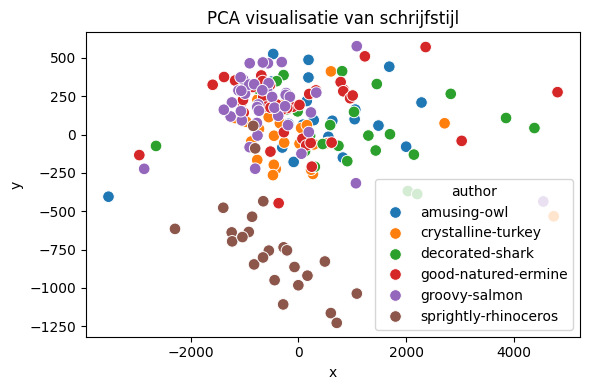

In [69]:
# 4. Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x="x", y="y", hue="author", palette="tab10", s=70)
plt.title("PCA visualisatie van schrijfstijl")
plt.tight_layout()
plt.show()

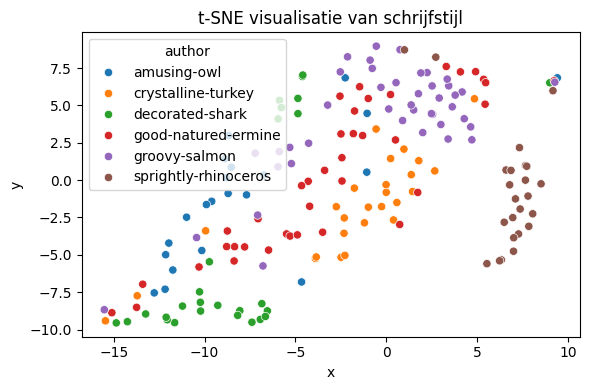

In [70]:
from sklearn.manifold import TSNE

# Maak een kopie van de data om niks te overschrijven
X_subset = X
labels = chunks_df['author'].reset_index(drop=True)

distance = manhattan_distances(X, X)
distance.shape, type(distance)

# Voer t-SNE uit
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(distance)

# Stop het in een dataframe voor plotten
tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "author": labels
})

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="author", palette="tab10")
plt.title("t-SNE visualisatie van schrijfstijl")
plt.tight_layout()
plt.show()

Je ziet dat sommige mensen, zoals sprightly-rhinoceros, echt hun eigen ‘cluster’ hebben hun stijl is dus vrij uniek. Anderen, zoals good-natured-ermine en groovy-salmon, liggen wat dichter bij elkaar, wat kan betekenen dat hun manier van typen iets meer op elkaar lijkt.

🔹 PCA (Principal Component Analysis) is als een vergrootglas dat kijkt naar de grootste verschillen in stijl tussen iedereen. Je ziet bijvoorbeeld dat sprightly-rhinoceros sterk afwijkt van de rest – blijkbaar schrijft die echt op z’n eigen manier.

🔸 t-SNE (t-Distributed Stochastic Neighbor Embedding) is meer een ‘vriendenkaartje’: het kijkt naar wie op wie lijkt, en zet die dichter bij elkaar. Daardoor zie je bijvoorbeeld dat sommige schrijfstijlen een beetje samensmelten (groovy-salmon en good-natured-ermine bijvoorbeeld).

In [71]:
chunks_df['message_length'] = df['message'].astype(str).str.len()
chunks_df.groupby('author')['message_length'].mean().sort_values(ascending=False)


author
amusing-owl             46.142857
good-natured-ermine     38.256410
sprightly-rhinoceros    31.208333
groovy-salmon           26.285714
decorated-shark         24.148148
crystalline-turkey      21.730769
Name: message_length, dtype: float64

In [102]:
import emoji

# Functie om aantal emoji's te tellen in een tekst
def count_emojis(text):
    return sum(1 for char in text if char in emoji.EMOJI_DATA)

# Kolom toevoegen aan je dataframe
chunks_df['emoji_count'] = chunks_df['text'].apply(count_emojis)
chunks_df.groupby('author')['emoji_count'].mean().sort_values(ascending=False)

author
sprightly-rhinoceros    41.583333
decorated-shark         26.777778
crystalline-turkey      24.269231
groovy-salmon           14.071429
good-natured-ermine     13.564103
amusing-owl              4.190476
Name: emoji_count, dtype: float64

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

dutch_stopwords = stopwords.words('dutch')

vectorizer = CountVectorizer(stop_words=dutch_stopwords)
author_messages = df[df['author'] == 'sprightly-rhinoceros']['message'].dropna().astype(str)
X_rhino = vectorizer.fit_transform(author_messages)

word_counts = X_rhino.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
top_rhino = pd.Series(word_counts, index=words).sort_values(ascending=False).head(20)
print(top_rhino)


haha             153
wel               50
goed              42
even              39
weer              30
super             29
gaaf              28
lekker            25
jep               25
nice              22
we                21
wij               21
gefeliciteerd     20
allemaal          18
hahaha            17
waar              16
net               15
denk              14
heel              14
oké               14
dtype: int64


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azureuser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


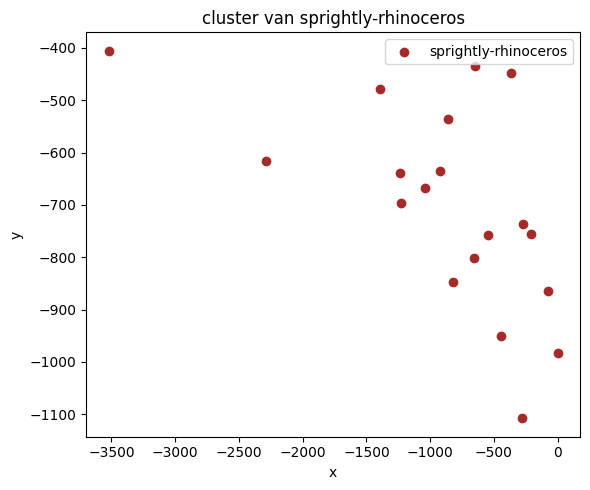

In [101]:
rhino = pca_df[
    (pca_df['x'] < 0) & 
    (pca_df['y'] < -300)  
]

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(rhino["x"], rhino["y"], color="brown", label="sprightly-rhinoceros")
plt.xlabel("x")
plt.ylabel("y")
plt.title("cluster van sprightly-rhinoceros")
plt.legend()
plt.tight_layout()
plt.show()


In [100]:
chunks_df["x"] = pca_df["x"]
chunks_df["y"] = pca_df["y"]

rhino = chunks_df[
    (chunks_df["x"] < 0) &
    (chunks_df["y"] < -300)
]

for i, row in rhino.head(5).iterrows():
    print(f"▶ Bericht {i}:\n{row['text']}\n")


▶ Bericht 20:
veel politie oow woow en in de tent 12 graden zou kunnen in de zon uit de wind haha kaartjes over ik heb kopers! ik zoek 1, kaartje voor morgen vroeger was nog 3 kratjes voor €9,99 haha die reclame er bij ook...🤗🙈 wij komen er zo aan. lekkerr haha wel poepen? en leuke foto van blue ook lekker echt hè hahah

▶ Bericht 74:
nu lekker genieten in jullie nieuwe huisje! 😘 (zeker als straks alles klaar is 💪🏼) son staat weer mooi op de kaart met al da eindhovens volk aan t woord 😅😂 wauw gaaf! lekkerrrr goed dat jullie gaan! 😂😂 hij was zo rood genoeg toch? netjes hoor de grasmaaiers weer aan het werk gezet. nieuw stukje dit hebben ze gister al mooi kort gegeten 😂 wauw!! ziet er super goed uit! dankjulliewel! ☺️ heel veel zin in! helaas de toekomst heeft gewonnen zéker jaaa zeker! zéker! super trots, maar toch balen 😉 😂😂😂 mmm 🥲 t gaat zo flink los ben ik bang 🙈 t koelde hier in huis in 5 minuten 10 graden af 😂😅 oh neeee om te bewaren tot ze 18 zijn? 😏 woooow!! zit er echt mega goed

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
import pandas as pd

# Vectoriseer
vectorizer = CountVectorizer(analyzer="char", ngram_range=(3, 3))
X = vectorizer.fit_transform(chunks_df["text"])
X_dense = X.toarray()

pca_features = PCA(n_components=2)
X_pca_features = pca_features.fit_transform(X_dense)

import pandas as pd

# Zet de PCA loadings in een dataframe
loadings = pd.DataFrame(
    pca_features.components_.T,
    columns=['PC1', 'PC2'],
    index=vectorizer.get_feature_names_out()
)

# Top 10 n-grams die het meest bijdragen aan PC1 (absolute waarde)
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
print("Top 10 belangrijkste n-grams voor PC1:")
print(loadings.loc[top_pc1.index])


🔍 Top 10 belangrijkste n-grams voor PC1:
          PC1       PC2
en   0.463900  0.431678
 ha -0.207615  0.281734
aha -0.202485  0.313319
hah -0.202041  0.320211
ha  -0.178327  0.271449
aar  0.160829  0.010407
 da  0.140234  0.101881
een  0.138035 -0.011090
 de  0.135513  0.052534
de   0.128474  0.058420


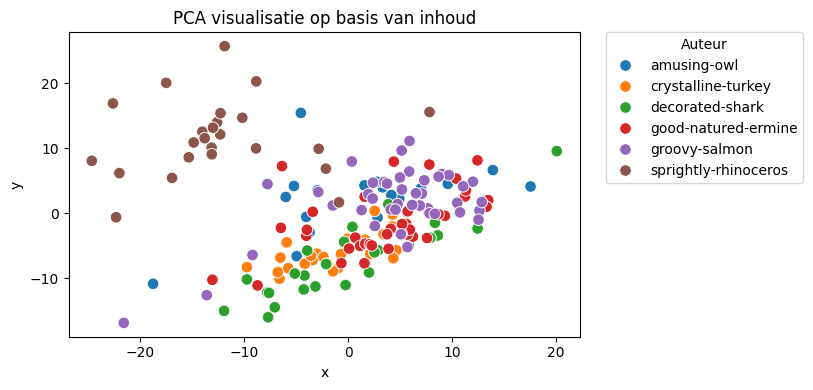

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pca = PCA(n_components=2)
pca_model = pca.fit_transform(X_dense)

# 3. Zet in DataFrame
pca_df = pd.DataFrame({
    "x": pca_model[:, 0],
    "y": pca_model[:, 1],
    "author": chunks_df["author"].values
})

# 4. Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x="x", y="y", hue="author", palette="tab10", s=70)
plt.title("PCA visualisatie op basis van inhoud")
plt.tight_layout()

plt.legend(
    title="Auteur",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.show()
